In [24]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Step 0 — Inputs you assume you already have

## For each subject:

-   A list of that subject’s electrode locations (3D MNI coordinates)

## For each session:

-   A matrix of voltage time series: timepoints × electrodes

-   A list of all locations you want to index the final matrix by

In the paper, this is “all electrode locations from everyone pooled together” (union across subjects).

A smoothing width value (lambda), set to 20 in the paper.

### The order of the electrode numbers in the data should match the order of the electrode locations, so that you can compute distances between them and apply the weights correctly.

In [25]:
# each subjects preprocessed voltage time series, in microvolts, per electrode
project_root = Path('/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project')
preprocessed_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')

subject_records = {}
for loc_path in sorted(preprocessed_dir.glob('*_locs_mni_mm.npy')):
    pid = loc_path.stem.split('_')[0]
    ecog_path = preprocessed_dir / f'{pid}_ecog_filtered.npy'
    stim_path = preprocessed_dir / f'{pid}_stim_nonzero.npy'
    if not ecog_path.exists() or not stim_path.exists():
        continue

    locs = np.load(loc_path).astype(np.float32, copy=False)
    ecog_shape = np.load(ecog_path, mmap_mode='r').shape
    stim_shape = np.load(stim_path, mmap_mode='r').shape

    subject_records[pid] = {
        'locs': locs,
        'ecog_path': ecog_path,
        'stim_path': stim_path,
    }
    print(f'[{pid}] locs={locs.shape} ecog={ecog_shape} stim={stim_shape}')

subject_ids = sorted(subject_records)
print(f'Loaded metadata for {len(subject_ids)} subjects from {preprocessed_dir}')

[aa] locs=(39, 3) ecog=(244200, 39) stim=(244200,)
[ap] locs=(40, 3) ecog=(241200, 40) stim=(241200,)
[ca] locs=(49, 3) ecog=(244200, 49) stim=(244200,)
[de] locs=(31, 3) ecog=(244200, 31) stim=(244200,)
[fp] locs=(50, 3) ecog=(244200, 50) stim=(244200,)
[ha] locs=(38, 3) ecog=(242200, 38) stim=(242200,)
[ja] locs=(54, 3) ecog=(244200, 54) stim=(244200,)
[jt] locs=(101, 3) ecog=(244200, 101) stim=(244200,)
[mv] locs=(58, 3) ecog=(244200, 58) stim=(244200,)
[rn] locs=(42, 3) ecog=(244240, 42) stim=(244240,)
[rr] locs=(40, 3) ecog=(162800, 40) stim=(162800,)
[wc] locs=(37, 3) ecog=(244200, 37) stim=(244200,)
[zt] locs=(56, 3) ecog=(244200, 56) stim=(244200,)
Loaded metadata for 13 subjects from /Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed


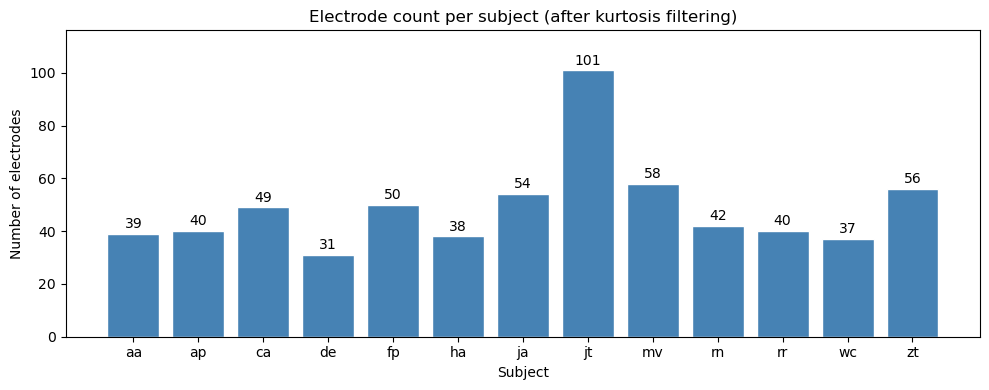

In [26]:
# Viz: electrode count per subject after kurtosis filtering
fig, ax = plt.subplots(figsize=(10, 4))
counts = [subject_records[pid]['locs'].shape[0] for pid in subject_ids]
bars = ax.bar(subject_ids, counts, color='steelblue', edgecolor='white')
ax.bar_label(bars, padding=2)
ax.set_xlabel('Subject')
ax.set_ylabel('Number of electrodes')
ax.set_title('Electrode count per subject (after kurtosis filtering)')
ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()

In [27]:
# All subjects' electrode locations in mni
all_locs_stack = np.vstack([subject_records[pid]['locs'] for pid in subject_ids])
_, first_idx = np.unique(all_locs_stack, axis=0, return_index=True)
all_electrodes = all_locs_stack[np.sort(first_idx)].astype(np.float32)
lambda_width = 20.0

print(f'Pooled unique electrode locations: {all_electrodes.shape}')
print(f'Gaussian smoothing width (lambda): {lambda_width}')

Pooled unique electrode locations: (532, 3)
Gaussian smoothing width (lambda): 20.0


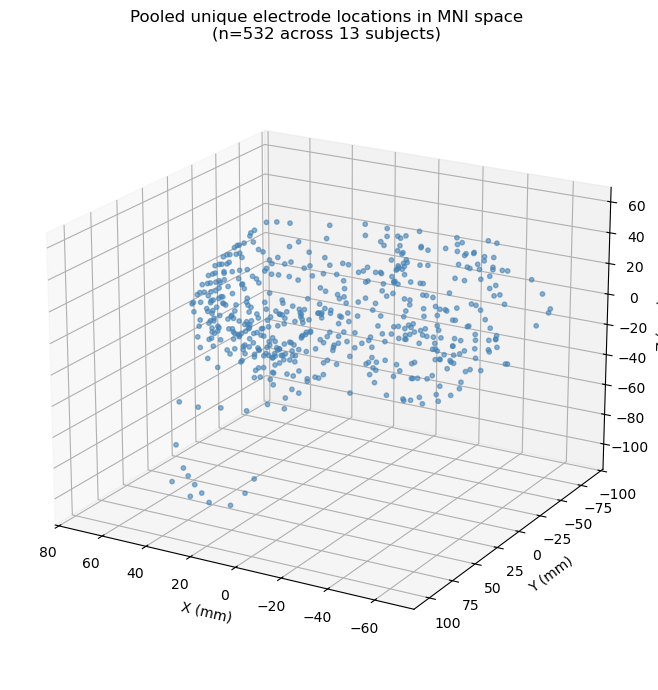

In [28]:
# Viz: 3D scatter of all pooled unique MNI electrode locations
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(all_electrodes[:, 0], all_electrodes[:, 1], all_electrodes[:, 2],
           s=10, alpha=0.6, c='steelblue')
ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Z (mm)')
ax.set_title(f'Pooled unique electrode locations in MNI space\n(n={all_electrodes.shape[0]} across {len(subject_ids)} subjects)')
ax.view_init(elev=20, azim=120)
plt.tight_layout()
plt.show()

# Step 1 — Per-subject electrode–electrode correlation matrix

**Goal:** For each subject $s$, compute the average pairwise Pearson correlation between all of their electrodes, averaged across stimulus presentation sessions.

---

### 1A — Pearson correlation per session

For session $k$ of subject $s$, with voltage matrix $V_k^{(s)}$ of shape (timepoints × electrodes):

$$R_k^{(s)} = \text{corr}\!\left(V_k^{(s)}\right) \qquad \text{shape: } E_s \times E_s$$

where $E_s$ = number of electrodes for subject $s$.

---

### 1B — Fisher-z averaging across sessions

Raw correlations can't be averaged directly (they live on $[-1, 1]$ and the scale compresses near the extremes). The **Fisher-z transform** maps them to $(-\infty, +\infty)$ where averaging is well-behaved:

$$z = \text{arctanh}(r) \qquad \longleftrightarrow \qquad r = \tanh(z)$$

Session-averaged correlation for subject $s$:

$$\bar{R}^{(s)} = \tanh\!\left(\frac{1}{N_\text{sess}} \sum_{k=1}^{N_\text{sess}} \text{arctanh}\!\left(R_k^{(s)}\right)\right)$$

**Output:** One symmetric $E_s \times E_s$ matrix $\bar{R}^{(s)}$ per subject.

```
FOR each subject s:

    # 1A — Pearson correlation for each stimulus session k
    FOR each session k:
        V_k  ← voltage matrix  (timepoints × E_s electrodes)
        R_k  ← corrcoef(V_k)   (E_s × E_s)

    # 1B — Fisher-z average across sessions
    #   z = arctanh(r)   maps [-1,1] → (-∞, +∞)
    #   r = tanh(z)      inverse
    #
    #   R̄^(s) = tanh( mean_k( arctanh(R_k) ) )

    z_stack   ← arctanh( stack of all R_k )    # (N_sess, E_s, E_s)
    mean_z    ← mean over session axis           # (E_s, E_s)
    R̄^(s)    ← tanh( mean_z )                  # (E_s, E_s)  ← OUTPUT
```

Step 1 complete — subject-level average electrode correlation matrices R̄^(s):
  [aa]  sessions=101  R̄^(s) shape=(39, 39)
  [ap]  sessions=101  R̄^(s) shape=(40, 40)
  [ca]  sessions=101  R̄^(s) shape=(49, 49)
  [de]  sessions=101  R̄^(s) shape=(31, 31)
  [fp]  sessions=101  R̄^(s) shape=(50, 50)
  [ha]  sessions=101  R̄^(s) shape=(38, 38)
  [ja]  sessions=101  R̄^(s) shape=(54, 54)
  [jt]  sessions=101  R̄^(s) shape=(101, 101)
  [mv]  sessions=101  R̄^(s) shape=(58, 58)
  [rn]  sessions=101  R̄^(s) shape=(42, 42)
  [rr]  sessions=101  R̄^(s) shape=(40, 40)
  [wc]  sessions=101  R̄^(s) shape=(37, 37)
  [zt]  sessions=101  R̄^(s) shape=(56, 56)


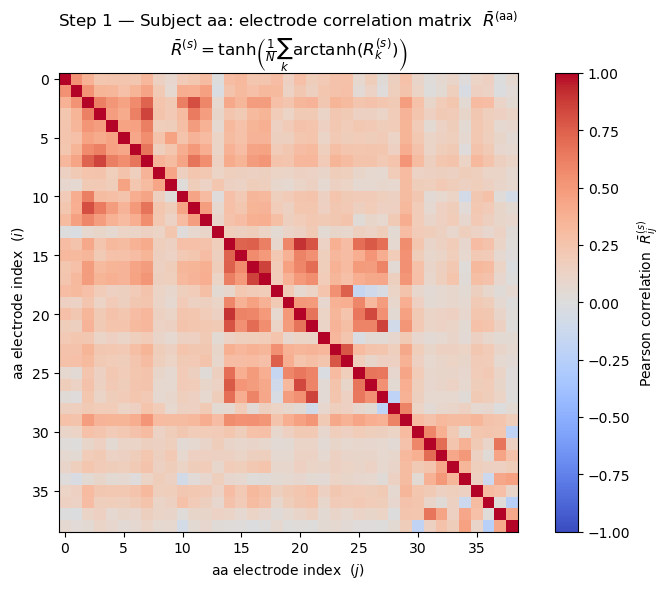

In [29]:
# Fisher-z helpers
#   fisher_z(r)         = arctanh(r)  — maps [-1,1] → (-∞,+∞) for linear averaging
#   inverse_fisher_z(z) = tanh(z)     — maps back
def fisher_z(corr_values):
    corr_values = np.clip(corr_values, -0.999999, 0.999999)
    return np.arctanh(corr_values)          # z = arctanh(r)

def inverse_fisher_z(z_values):
    return np.tanh(z_values)                # r = tanh(z)


subject_session_correlation_matrices = {}
subject_average_correlation_matrices = {}

for pid in subject_ids:
    ecog = np.load(subject_records[pid]['ecog_path'], mmap_mode='r')  # (T, E_s)
    stim = np.load(subject_records[pid]['stim_path']).ravel()          # (T,)

    session_corrs = []
    for stim_id in np.unique(stim):
        stim_mask = stim == stim_id
        if np.count_nonzero(stim_mask) < 2:
            continue

        # 1A: R_k^(s) = corrcoef( V_k )   shape: (E_s, E_s)
        session_data = ecog[stim_mask]                                 # (T_k, E_s)
        corr_matrix = np.corrcoef(session_data, rowvar=False)          # (E_s, E_s)
        corr_matrix = np.nan_to_num(corr_matrix, nan=0.0, posinf=0.0, neginf=0.0)
        np.fill_diagonal(corr_matrix, 1.0)
        session_corrs.append(corr_matrix.astype(np.float32, copy=False))

    if not session_corrs:
        raise ValueError(f'No valid session correlation matrices for subject {pid}')

    # 1B: R̄^(s) = tanh( mean_k( arctanh(R_k^(s)) ) )
    z_stack          = fisher_z(np.stack(session_corrs, axis=0))   # arctanh each R_k
    mean_z           = z_stack.mean(axis=0)                         # average in z-space
    subject_avg_corr = inverse_fisher_z(mean_z).astype(np.float32, copy=False)  # tanh back
    subject_avg_corr = 0.5 * (subject_avg_corr + subject_avg_corr.T)  # enforce symmetry
    np.fill_diagonal(subject_avg_corr, 1.0)

    subject_session_correlation_matrices[pid] = session_corrs
    subject_average_correlation_matrices[pid] = subject_avg_corr   # R̄^(s): (E_s, E_s)

print('Step 1 complete — subject-level average electrode correlation matrices R̄^(s):')
for pid in subject_ids:
    n_sessions = len(subject_session_correlation_matrices[pid])
    corr_shape = subject_average_correlation_matrices[pid].shape
    print(f'  [{pid}]  sessions={n_sessions}  R̄^(s) shape={corr_shape}')

# Visualise R̄^(aa)
if 'aa' in subject_average_correlation_matrices:
    aa_corr = subject_average_correlation_matrices['aa']
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(aa_corr, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, label=r'Pearson correlation  $\bar{R}^{(s)}_{ij}$')
    ax.set_title(
        r'Step 1 — Subject aa: electrode correlation matrix  $\bar{R}^{(\mathrm{aa})}$' + '\n' +
        r'$\bar{R}^{(s)} = \tanh\!\left(\frac{1}{N}\sum_k \mathrm{arctanh}(R_k^{(s)})\right)$'
    )
    ax.set_xlabel(r'aa electrode index  $(j)$')
    ax.set_ylabel(r'aa electrode index  $(i)$')
    plt.tight_layout()
    plt.show()
else:
    print("Subject 'aa' not found; skipped Step 1 plot.")

# Step 2 — Gaussian distance weights &nbsp;&nbsp;*(Paper Eq. 1)*

**Goal:** For each subject $s$, build a weight matrix $\mathbf{W}^{(s)}$ that encodes how much each of their electrodes should inform each *pooled* MNI location.

---

### Eq. 1 — Gaussian kernel

$$\boxed{w_{ij} = \exp\!\left(-\frac{\|\,x_i - x_j\,\|^2}{\lambda}\right)}$$

| Symbol | Meaning |
|--------|---------|
| $x_i \in \mathbb{R}^3$ | MNI coordinate of **pooled location** $i$ (union of all subjects' electrodes) |
| $x_j \in \mathbb{R}^3$ | MNI coordinate of **subject electrode** $j$ |
| $\lambda = 20\ \text{mm}$ | Smoothing bandwidth — controls how far each electrode's influence reaches |
| $w_{ij} \to 1$ | Electrode $j$ is co-located with pooled location $i$ |
| $w_{ij} \to 0$ | Electrode $j$ is far from pooled location $i$ |

The key intuition: **an electrode only informs locations that are physically near it in the brain.** Locations with no nearby electrodes get weight ≈ 0 from this subject.

**Output:** $\mathbf{W}^{(s)}$ of shape $\underbrace{L}_{\text{pooled locs}} \times \underbrace{E_s}_{\text{subject electrodes}}$ — one matrix per subject.

```
FOR each subject s:

    W^(s) ← zeros(L, E_s)          # L pooled locs, E_s subject electrodes

    FOR each pooled location i  (coordinate x_i):
        FOR each subject electrode j  (coordinate x_j):

            # squared Euclidean distance in MNI space
            d²_ij  = ||x_i − x_j||²

            # Eq. 1: Gaussian falloff
            W^(s)[i, j] = exp( −d²_ij / λ )    # λ = 20 mm

    # W^(s) shape: (L × E_s)
    # Each row  i : how much every electrode informs pooled location i
    # Each col  j : how much electrode j informs every pooled location
    #              → a Gaussian "blob" centred on electrode j's MNI position
```

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# Paper Eq. 1 — Gaussian distance kernel:
#
#   w_ij = exp( −||x_i − x_j||² / λ )
#
#   i  → index over pooled MNI locations    (L = 532 rows)
#   j  → index over subject electrodes      (E_s columns)
#   λ  → smoothing bandwidth = 20 mm        (lambda_width)
#
#   W^(s) shape: (L × E_s)
#     W[i, j] → 1  when pooled location i ≈ electrode j
#     W[i, j] → 0  as Euclidean distance between them grows
# ─────────────────────────────────────────────────────────────────────────────
subject_weights = {}

for pid in subject_ids:
    subject_locs = subject_records[pid]['locs']              # x_j : (E_s, 3)

    # broadcast subtract: (L,1,3) − (1,E_s,3)  →  (L, E_s, 3)
    diffs = all_electrodes[:, None, :] - subject_locs[None, :, :]

    # ||x_i − x_j||²  element-wise  →  (L, E_s)
    distance_squared = np.sum(diffs * diffs, axis=2)

    # Eq. 1:  w_ij = exp( −||x_i − x_j||² / λ )
    weights = np.exp(-distance_squared / lambda_width).astype(np.float32, copy=False)

    subject_weights[pid] = weights                           # W^(s) : (L, E_s)

print('Step 2 complete — Gaussian weight matrices W^(s)  (Eq. 1):')
for pid in subject_ids:
    print(f'  [{pid}]  W^(s) shape={subject_weights[pid].shape}')

Step 2 complete — Gaussian weight matrices W^(s)  (Eq. 1):
  [aa]  W^(s) shape=(532, 39)
  [ap]  W^(s) shape=(532, 40)
  [ca]  W^(s) shape=(532, 49)
  [de]  W^(s) shape=(532, 31)
  [fp]  W^(s) shape=(532, 50)
  [ha]  W^(s) shape=(532, 38)
  [ja]  W^(s) shape=(532, 54)
  [jt]  W^(s) shape=(532, 101)
  [mv]  W^(s) shape=(532, 58)
  [rn]  W^(s) shape=(532, 42)
  [rr]  W^(s) shape=(532, 40)
  [wc]  W^(s) shape=(532, 37)
  [zt]  W^(s) shape=(532, 56)


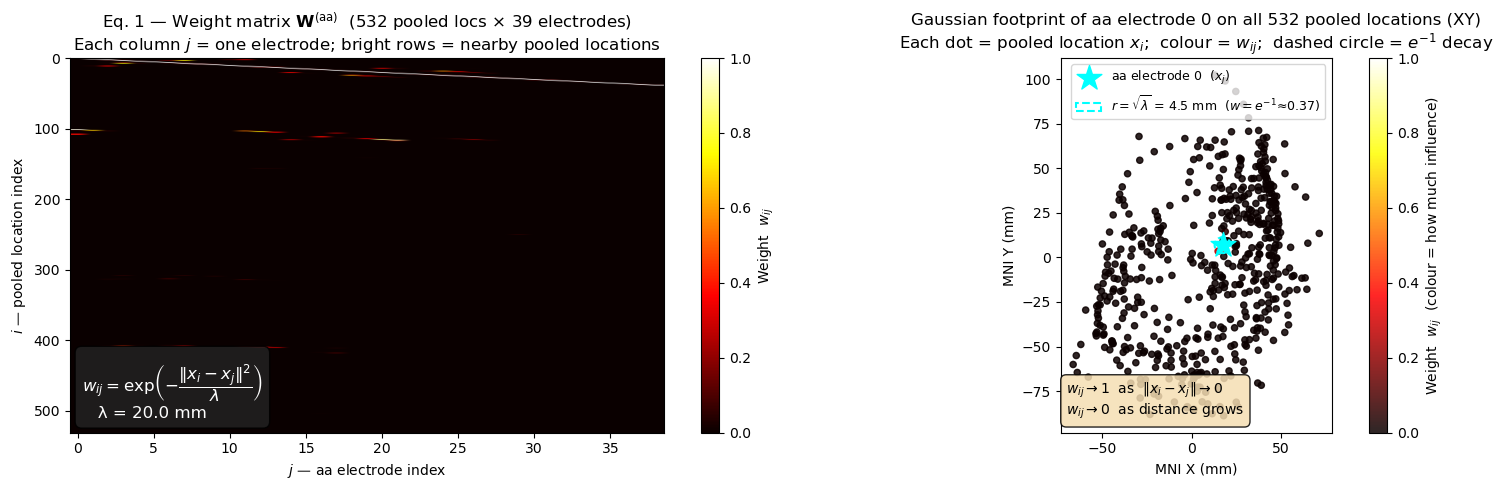

In [31]:
# Viz: Step 2 — weight matrix W^(s) for subject 'aa'
pid_ex = 'aa'
W = subject_weights[pid_ex]   # (L, E_s) = (532, 39)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: full heatmap  W^(s)  ──────────────────────────────────────────────
im = axes[0].imshow(W, aspect='auto', cmap='hot', vmin=0, vmax=1)
plt.colorbar(im, ax=axes[0], label=r'Weight  $w_{ij}$')
axes[0].set_xlabel(r'$j$ — aa electrode index')
axes[0].set_ylabel(r'$i$ — pooled location index')
axes[0].set_title(
    r'Eq. 1 — Weight matrix $\mathbf{W}^{(\mathrm{aa})}$  (532 pooled locs × 39 electrodes)' + '\n'
    r'Each column $j$ = one electrode; bright rows = nearby pooled locations'
)
# Formula box on the plot
axes[0].text(
    0.02, 0.03,
    r'$w_{ij} = \exp\!\left(-\dfrac{\|x_i - x_j\|^2}{\lambda}\right)$'
    + f'\n   λ = {lambda_width} mm',
    transform=axes[0].transAxes, fontsize=12, va='bottom', color='white',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#222222', alpha=0.85)
)

# ── Right: one electrode's Gaussian footprint in MNI space (XY plane)  ──────
# pick the electrode with the strongest peak weight across all pooled locations
col_idx    = int(np.argmax(W.max(axis=0)))
w_col      = W[:, col_idx]                                # weights for electrode col_idx
elec_coord = subject_records[pid_ex]['locs'][col_idx]     # MNI position x_j

sc = axes[1].scatter(
    all_electrodes[:, 0], all_electrodes[:, 1],
    c=w_col, cmap='hot', s=20, alpha=0.85, vmin=0, vmax=1
)
plt.colorbar(sc, ax=axes[1], label=r'Weight  $w_{ij}$  (colour = how much influence)')
axes[1].scatter(
    elec_coord[0], elec_coord[1],
    marker='*', s=350, c='cyan', zorder=5,
    label=fr'aa electrode {col_idx}  ($x_j$)'
)
# draw circle at λ^0.5 radius to show the e^-1 decay ring
circle = plt.Circle(
    (elec_coord[0], elec_coord[1]),
    radius=lambda_width**0.5,
    fill=False, edgecolor='cyan', linestyle='--', linewidth=1.5,
    label=fr'$r = \sqrt{{\lambda}}$ = {lambda_width**0.5:.1f} mm  ($w = e^{{-1}} ≈ 0.37$)'
)
axes[1].add_patch(circle)
axes[1].set_xlabel('MNI X (mm)')
axes[1].set_ylabel('MNI Y (mm)')
axes[1].set_title(
    fr'Gaussian footprint of aa electrode {col_idx} on all 532 pooled locations (XY)' + '\n'
    r'Each dot = pooled location $x_i$;  colour = $w_{ij}$;  dashed circle = $e^{-1}$ decay'
)
axes[1].text(
    0.02, 0.03,
    r'$w_{ij} \to 1$  as  $\|x_i - x_j\| \to 0$' + '\n'
    r'$w_{ij} \to 0$  as distance grows',
    transform=axes[1].transAxes, fontsize=10, va='bottom',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='wheat', alpha=0.85)
)
axes[1].legend(fontsize=9)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

# Step 3A — Subject-specific full-brain correlation matrix &nbsp;&nbsp;*(Paper Eq. 6)*

**Goal:** Use subject $s$'s electrode correlations $\bar{R}^{(s)}$ (Step 1) and Gaussian weights $\mathbf{W}^{(s)}$ (Step 2) to estimate the correlation between **any two pooled MNI locations** — including locations where subject $s$ has no electrode.

---

### Eq. 6 — Gaussian-weighted interpolation

**Scalar form** (element $K^{(s)}_{ab}$ = estimated correlation between pooled locations $a$ and $b$):

$$K^{(s)}_{ab} = \tanh\!\left(\frac{\displaystyle\sum_{i,j}\, w_{ai}\, w_{bj}\; \text{arctanh}\!\left(\bar{R}^{(s)}_{ij}\right)}{\displaystyle\sum_{i,j}\, w_{ai}\, w_{bj}}\right)$$

**Matrix form** (equivalent — and what the code actually computes):

$$\boxed{\mathbf{K}^{(s)} = \tanh\!\left(\frac{\mathbf{W}^{(s)}\;\text{arctanh}\!\left(\bar{\mathbf{R}}^{(s)}\right)\;{\mathbf{W}^{(s)}}^\top}{\mathbf{W}^{(s)}\;\mathbf{1}\;{\mathbf{W}^{(s)}}^\top}\right)}$$

| Term | Shape | Role |
|------|-------|------|
| $\mathbf{W}^{(s)}$ | $L \times E_s$ | Gaussian weights (Step 2 / Eq. 1) |
| $\bar{\mathbf{R}}^{(s)}$ | $E_s \times E_s$ | Subject electrode correlations (Step 1) |
| $\mathbf{1}$ | $E_s \times E_s$ | All-ones matrix — normalises by total weight |
| $\mathbf{K}^{(s)}$ | $L \times L$ | Estimated full-brain correlation matrix |

The division is **element-wise**. Where a subject has no electrodes near a pooled location, the denominator ≈ 0 and that entry is zeroed out (eps guard in code).

**Output:** One $(L \times L)$ matrix $\mathbf{K}^{(s)}$ per subject. With $L = 532$, this is a $532 \times 532$ estimated full-brain correlation structure derived entirely from that subject's sparse electrode coverage.

```
FOR each subject s:

    R̄^(s)   ← subject_average_correlation_matrices[s]   # (E_s × E_s)  from Step 1
    W^(s)   ← subject_weights[s]                         # (L  × E_s)  from Step 2

    # --- Matrix form of Eq. 6 ---

    # Fisher-z the electrode correlations first
    Z^(s)        = arctanh( R̄^(s) )                     # (E_s × E_s)

    # Numerator:   W @ arctanh(R̄) @ Wᵀ
    numerator    = W^(s)  @  Z^(s)  @  W^(s)ᵀ           # (L × L)
    #   Each entry (a,b): Σ_{i,j} w_ai · arctanh(R̄_ij) · w_bj

    # Denominator: W @ ones @ Wᵀ   (= sum of all pairwise weights)
    denominator  = W^(s)  @  ones(E_s,E_s)  @  W^(s)ᵀ   # (L × L)
    #   Each entry (a,b): Σ_{i,j} w_ai · w_bj

    # Eq. 6 complete:
    K^(s) = tanh( numerator / denominator )               # (L × L)  ← OUTPUT
    #   = tanh( Σ w_ai·w_bj·arctanh(R̄_ij) / Σ w_ai·w_bj )
```

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# Paper Eq. 6 — Gaussian-weighted interpolation (matrix form):
#
#   Scalar:  K^(s)_ab = tanh( Σ_{i,j} w_ai·w_bj·arctanh(R̄^(s)_ij)
#                             / Σ_{i,j} w_ai·w_bj )
#
#   Matrix:  K^(s) = tanh( numerator / denominator )   [element-wise /]
#     where
#       numerator   = W^(s)  @  arctanh(R̄^(s))  @  W^(s)ᵀ   (L × L)
#       denominator = W^(s)  @  ones(E_s,E_s)    @  W^(s)ᵀ   (L × L)
#
#   W^(s)  : (L × E_s)  Gaussian weights          [Step 2 / Eq. 1]
#   R̄^(s)  : (E_s × E_s) electrode correlations   [Step 1]
#   K^(s)  : (L × L)    estimated full-brain correlation
#
#   Denominator ≈ 0 where a subject has no nearby electrodes → zeroed out.
# ─────────────────────────────────────────────────────────────────────────────
subject_full_matrices = {}
eps = 1e-12

for pid in subject_ids:
    electrode_corr = subject_average_correlation_matrices[pid]   # R̄^(s) : (E_s, E_s)
    weights        = subject_weights[pid]                         # W^(s)  : (L,   E_s)

    # Fisher-z the electrode correlations: arctanh( R̄^(s) )
    corr_z      = fisher_z(electrode_corr).astype(np.float32, copy=False)  # (E_s, E_s)

    # numerator:   W^(s) @ arctanh(R̄^(s)) @ W^(s)ᵀ
    numerator   = weights @ corr_z @ weights.T                   # (L, L)

    # denominator: W^(s) @ ones @ W^(s)ᵀ   (sum of all pairwise weights)
    denominator = weights @ np.ones_like(corr_z, dtype=np.float32) @ weights.T  # (L, L)

    # element-wise division (eps guard where denominator ≈ 0)
    mean_z = np.divide(
        numerator,
        denominator,
        out=np.zeros_like(numerator, dtype=np.float32),
        where=denominator > eps,
    )

    # Eq. 6 complete: K^(s) = tanh( numerator / denominator )
    subject_full_matrix = inverse_fisher_z(mean_z).astype(np.float32, copy=False)
    subject_full_matrix = 0.5 * (subject_full_matrix + subject_full_matrix.T)  # symmetry
    np.fill_diagonal(subject_full_matrix, 1.0)

    subject_full_matrices[pid] = subject_full_matrix             # K^(s) : (L, L)

print('Step 3A complete — subject-specific full-brain matrices K^(s)  (Eq. 6):')
for pid in subject_ids:
    print(f'  [{pid}]  K^(s) shape={subject_full_matrices[pid].shape}')

Step 3A complete — subject-specific full-brain matrices K^(s)  (Eq. 6):
  [aa]  K^(s) shape=(532, 532)
  [ap]  K^(s) shape=(532, 532)
  [ca]  K^(s) shape=(532, 532)
  [de]  K^(s) shape=(532, 532)
  [fp]  K^(s) shape=(532, 532)
  [ha]  K^(s) shape=(532, 532)
  [ja]  K^(s) shape=(532, 532)
  [jt]  K^(s) shape=(532, 532)
  [mv]  K^(s) shape=(532, 532)
  [rn]  K^(s) shape=(532, 532)
  [rr]  K^(s) shape=(532, 532)
  [wc]  K^(s) shape=(532, 532)
  [zt]  K^(s) shape=(532, 532)


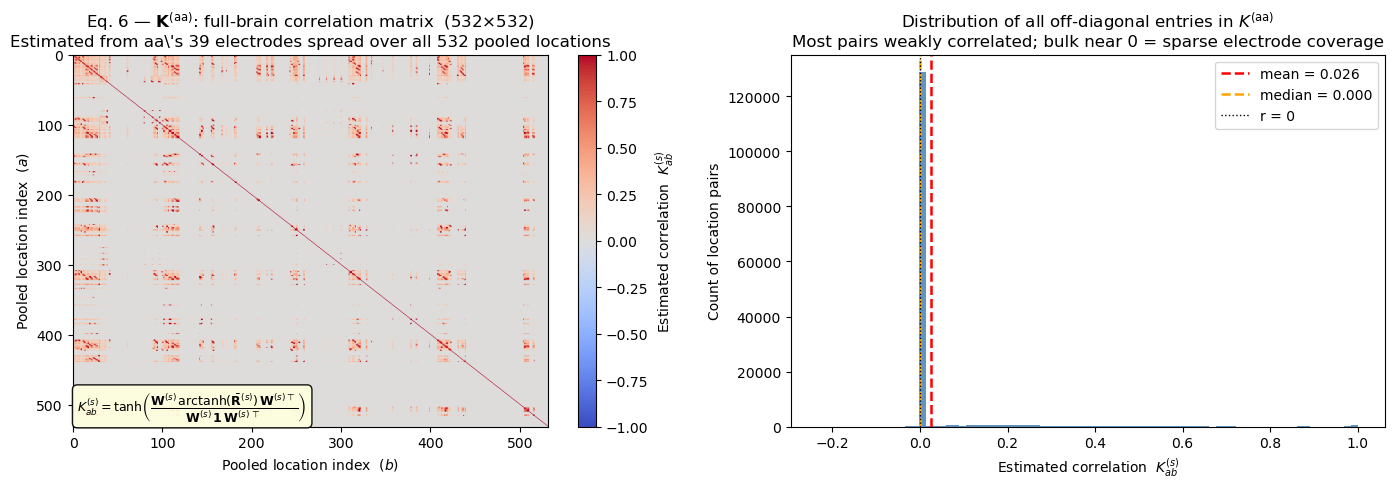

In [33]:
# Viz: Step 3A — subject 'aa' full-brain matrix K^(s)
pid_ex = 'aa'
M  = subject_full_matrices[pid_ex]       # K^(aa) : (532, 532)
n_elec = subject_records[pid_ex]['locs'].shape[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: heatmap of K^(s) ──────────────────────────────────────────────────
im = axes[0].imshow(M, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=axes[0], label=r'Estimated correlation  $K^{(s)}_{ab}$')
axes[0].set_xlabel(r'Pooled location index  $(b)$')
axes[0].set_ylabel(r'Pooled location index  $(a)$')
axes[0].set_title(
    fr'Eq. 6 — $\mathbf{{K}}^{{(\mathrm{{{pid_ex}}})}}$: full-brain correlation matrix  ({M.shape[0]}×{M.shape[0]})' + '\n'
    fr'Estimated from {pid_ex}\'s {n_elec} electrodes spread over all {M.shape[0]} pooled locations'
)
# Formula box
axes[0].text(
    0.01, 0.01,
    r'$K^{(s)}_{ab} = \tanh\!\left(\dfrac{\mathbf{W}^{(s)}\,\mathrm{arctanh}(\bar{\mathbf{R}}^{(s)})\,{\mathbf{W}^{(s)}}^\top}{\mathbf{W}^{(s)}\,\mathbf{1}\,{\mathbf{W}^{(s)}}^\top}\right)$',
    transform=axes[0].transAxes, fontsize=9, va='bottom',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.92)
)

# ── Right: distribution of off-diagonal K^(s) values ───────────────────────
triu_vals = M[np.triu_indices(M.shape[0], k=1)]
axes[1].hist(triu_vals, bins=80, color='steelblue', edgecolor='none', alpha=0.85)
axes[1].axvline(triu_vals.mean(),   color='red',    linestyle='--', lw=1.8,
                label=f'mean = {triu_vals.mean():.3f}')
axes[1].axvline(np.median(triu_vals), color='orange', linestyle='--', lw=1.8,
                label=f'median = {np.median(triu_vals):.3f}')
axes[1].axvline(0, color='black', linestyle=':', lw=1, label='r = 0')
axes[1].set_xlabel(r'Estimated correlation  $K^{(s)}_{ab}$')
axes[1].set_ylabel('Count of location pairs')
axes[1].set_title(
    fr'Distribution of all off-diagonal entries in $K^{{(\mathrm{{{pid_ex}}})}}$' + '\n'
    r'Most pairs weakly correlated; bulk near 0 = sparse electrode coverage'
)
axes[1].legend()

plt.tight_layout()
plt.show()

# Step 3B — Across-subject average correlation matrix &nbsp;&nbsp;*(Paper Eq. 7)*

**Goal:** Collapse the $S$ subject-specific matrices $\mathbf{K}^{(s)}$ into a single group-level full-brain correlation matrix using the same Fisher-z trick as Step 1 — but now averaging across subjects instead of sessions:

$$\boxed{\mathbf{K} = \tanh\!\left(\frac{1}{S} \sum_{s=1}^{S} \text{arctanh}\!\left(\mathbf{K}^{(s)}\right)\right)}$$

This is **Eq. 7** from the paper. Each subject contributes equally; the Fisher-z ensures the average is taken in a space where correlations combine linearly.

**Output:** One symmetric $(L \times L)$ matrix $\mathbf{K}$ — the group-level estimated pairwise correlation structure across all $L = 532$ pooled brain locations.

```
# Eq. 7 — Fisher-z average of subject-specific K matrices

all_K  ← stack( K^(s) for all subjects s )    # (S, L, L)

# same Fisher-z trick as Step 1, now across subjects instead of sessions
mean_z ← mean_s( arctanh( all_K ) )           # (L, L)
K      ← tanh( mean_z )                        # (L, L)  ← OUTPUT  (group-level)
```

Step 3B complete — across-subject matrix K  (Eq. 7):
  shape = (532, 532)
  min=-0.0559  max=1.0000
  max symmetry error = 0.00e+00


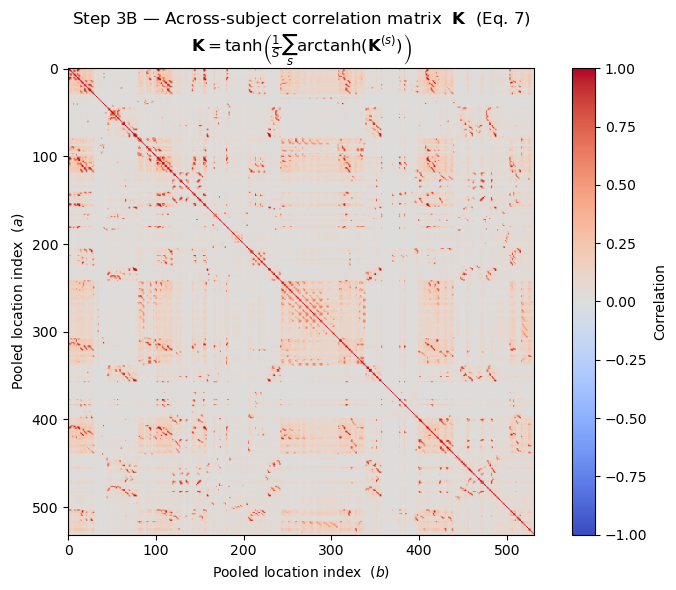

Saved to /Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/electrode_correlation_outputs.npz


In [34]:
# Eq. 7 — Fisher-z average across subjects:
#   K = tanh( (1/S) · Σ_s arctanh( K^(s) ) )
all_subject_full_matrices = np.stack(
    [subject_full_matrices[pid] for pid in subject_ids], axis=0
)  # (S, L, L)

# (1/S) Σ_s arctanh(K^(s))  — average in Fisher-z space
mean_z = fisher_z(all_subject_full_matrices).mean(axis=0)       # (L, L)

# tanh(·)  — inverse Fisher-z back to correlation scale
across_subject_correlation_matrix = inverse_fisher_z(mean_z).astype(np.float32, copy=False)
across_subject_correlation_matrix = 0.5 * (
    across_subject_correlation_matrix + across_subject_correlation_matrix.T
)
np.fill_diagonal(across_subject_correlation_matrix, 1.0)

print('Step 3B complete — across-subject matrix K  (Eq. 7):')
print(f'  shape = {across_subject_correlation_matrix.shape}')
print(f'  min={across_subject_correlation_matrix.min():.4f}  max={across_subject_correlation_matrix.max():.4f}')
print(f'  max symmetry error = {np.abs(across_subject_correlation_matrix - across_subject_correlation_matrix.T).max():.2e}')

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(across_subject_correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Correlation')
ax.set_title(
    r'Step 3B — Across-subject correlation matrix  $\mathbf{K}$  (Eq. 7)' + '\n' +
    r'$\mathbf{K} = \tanh\!\left(\frac{1}{S}\sum_s \mathrm{arctanh}(\mathbf{K}^{(s)})\right)$'
)
ax.set_xlabel('Pooled location index  $(b)$')
ax.set_ylabel('Pooled location index  $(a)$')
plt.tight_layout()
plt.show()

output_path = project_root / 'electrode_correlation_outputs.npz'
np.savez_compressed(
    output_path,
    pooled_locations_mni_mm=all_electrodes,
    subject_ids=np.array(subject_ids, dtype=object),
    subject_full_matrices=all_subject_full_matrices,
    across_subject_correlation_matrix=across_subject_correlation_matrix,
)
print(f'Saved to {output_path}')

# Step 3C — Build **leakage-free** K for a held-out subject

To avoid leakage, when reconstructing subject `s`, build `K` using **all other subjects only** (exclude `s`).

- `K_no_leak[held_out_pid]` = average of subject full matrices from `subject_ids \ {held_out_pid}`
- Averaging uses Fisher-z, then inverse Fisher-z (same as Step 3B)


Held-out subject: aa
Training subjects used to build K: 12
K_no_leak shape: (532, 532)
min=-0.0605 max=1.0000
max_symmetry_error=0.000000


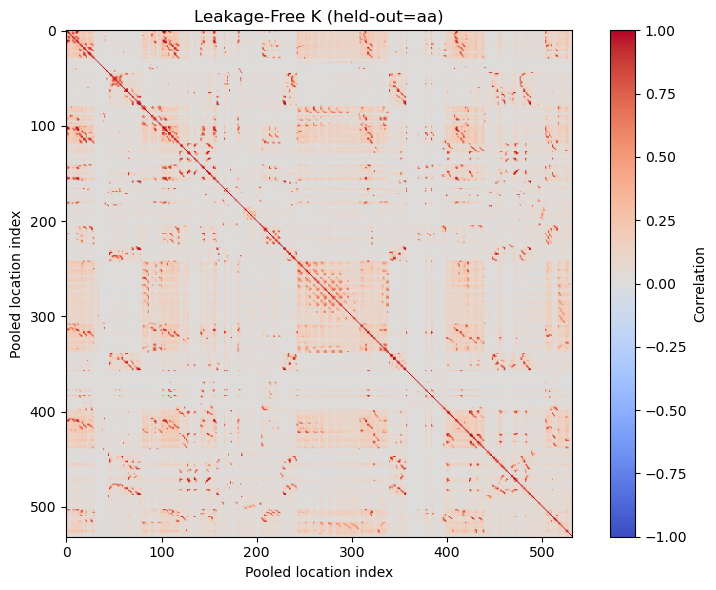

Built leakage-free K matrices for 13 held-out subjects.
Saved leakage-free outputs to /Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/electrode_correlation_outputs_no_leak.npz


In [35]:
# Choose the subject you plan to reconstruct/evaluate
held_out_pid = 'aa'  # <- change as needed
assert held_out_pid in subject_ids, f'{held_out_pid} not found in subject_ids'

train_ids = [pid for pid in subject_ids if pid != held_out_pid]
assert len(train_ids) > 0, 'Need at least one training subject after hold-out'

train_full_matrices = np.stack([subject_full_matrices[pid] for pid in train_ids], axis=0)

mean_z = fisher_z(train_full_matrices).mean(axis=0)
K_no_leak = inverse_fisher_z(mean_z).astype(np.float32, copy=False)
K_no_leak = 0.5 * (K_no_leak + K_no_leak.T)
np.fill_diagonal(K_no_leak, 1.0)

print(f'Held-out subject: {held_out_pid}')
print(f'Training subjects used to build K: {len(train_ids)}')
print(f'K_no_leak shape: {K_no_leak.shape}')
print(f'min={K_no_leak.min():.4f} max={K_no_leak.max():.4f}')
print(f'max_symmetry_error={np.abs(K_no_leak - K_no_leak.T).max():.6f}')

plt.figure(figsize=(8, 6))
im = plt.imshow(K_no_leak, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, label='Correlation')
plt.title(f'Leakage-Free K (held-out={held_out_pid})')
plt.xlabel('Pooled location index')
plt.ylabel('Pooled location index')
plt.tight_layout()
plt.show()

# Optional: build one leakage-free K per possible held-out subject
K_no_leak_by_subject = {}
for test_pid in subject_ids:
    train_ids_i = [pid for pid in subject_ids if pid != test_pid]
    train_stack_i = np.stack([subject_full_matrices[pid] for pid in train_ids_i], axis=0)

    mean_z_i = fisher_z(train_stack_i).mean(axis=0)
    K_i = inverse_fisher_z(mean_z_i).astype(np.float32, copy=False)
    K_i = 0.5 * (K_i + K_i.T)
    np.fill_diagonal(K_i, 1.0)

    K_no_leak_by_subject[test_pid] = K_i

print(f'Built leakage-free K matrices for {len(K_no_leak_by_subject)} held-out subjects.')

# Save both the chosen K and all leave-one-subject-out K matrices
output_path_no_leak = project_root / 'electrode_correlation_outputs_no_leak.npz'
np.savez_compressed(
    output_path_no_leak,
    pooled_locations_mni_mm=all_electrodes,
    subject_ids=np.array(subject_ids, dtype=object),
    held_out_pid=held_out_pid,
    train_ids_for_held_out=np.array(train_ids, dtype=object),
    K_no_leak=K_no_leak,
    K_no_leak_by_subject=np.array([K_no_leak_by_subject[pid] for pid in subject_ids]),
)
print(f'Saved leakage-free outputs to {output_path_no_leak}')
